# Week 2 Assignment — Machine Learning for Forecasting
### Multi-Agent Forecasting Project

**Name: Snehil Chatterjee**  
**Date: 16/06/26**  

---

This assignment builds directly on Week 1. You already know how to explore and decompose a time series — now you'll learn how to *forecast* one using machine learning models. By the end, you'll have built and evaluated multiple forecasting approaches on a real-world dataset.

**Topics covered:**
1. Linear Regression with Time Features (Trend Modelling)
2. Modelling Seasonality with Fourier Features
3. Lag Features & Serial Dependence
4. Decision Trees, Random Forests, and XGBoost for Time Series
5. Hybrid Models: Linear + XGBoost
6. Putting It All Together — Multi-Step Forecasting

> **Dataset:** We'll use the **Melbourne Daily Minimum Temperatures** dataset (1981–1990) for Sections 1–5 — it has a clear annual seasonal pattern and manageable size. Section 6 returns to the **Air Passengers** dataset from Week 1.

In [27]:
# Run this cell first — installs/imports everything you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Load dataset ──────────────────────────────────────────────────────────────
# Daily minimum temperatures in Melbourne, Australia (1981–1990)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.columns = ['temp']

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (3650, 1)
            temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


---
## Section 1 — Linear Regression with Time Features (Trend Modelling)

The simplest way to model a trend is to use **time itself as a feature**. We create a numeric counter `t = 0, 1, 2, ...` for each time step and fit a linear model:

$$\hat{y}_t = w_0 + w_1 \cdot t$$

For a curved trend, we extend this to a **polynomial** by adding $t^2$, $t^3$, etc.

`DeterministicProcess` from `statsmodels` makes this easy — `order=1` gives a linear trend, `order=2` gives quadratic, and so on.

**Read:** [`DeterministicProcess` docs](https://www.statsmodels.org/stable/generated/statsmodels.tsa.deterministic.DeterministicProcess.html)

In [28]:
# --- EXAMPLE: Fitting a linear trend with DeterministicProcess ---

dp_example = DeterministicProcess(
    index=df.index,
    constant=True,   # adds an intercept column
    order=1,         # linear trend (t)
    drop=True,       # drop perfectly collinear terms
)

X_example = dp_example.in_sample()   # feature matrix for training period
print("Feature matrix shape:", X_example.shape)
print(X_example.head())

Feature matrix shape: (3650, 2)
            const  trend
Date                    
1981-01-01    1.0    1.0
1981-01-02    1.0    2.0
1981-01-03    1.0    3.0
1981-01-04    1.0    4.0
1981-01-05    1.0    5.0


### Exercise 1.1 — Fit a Linear Trend

Using `DeterministicProcess` with `order=1`, fit a `LinearRegression` model to predict `temp`. Then:
1. Store fitted values in `y_trend`
2. Plot the original series and the trend line on the same axes
3. Print the slope coefficient (`model.coef_`) and intercept (`model.intercept_`). In one sentence, explain what the slope tells you about the temperature series.

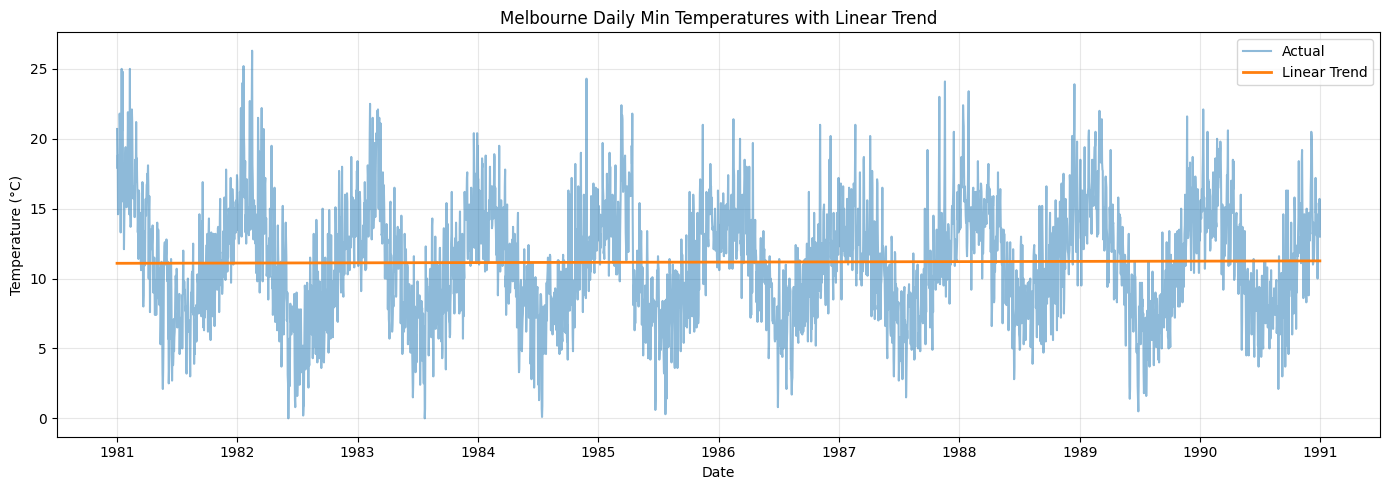

Slope (coef_): [0.00000000e+00 4.70627735e-05]
Intercept:     11.091840331560158


In [29]:
# YOUR CODE HERE
y = df['temp'].copy()

# 1. Build DeterministicProcess with linear trend
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    drop=True,
)

# 2. Create in-sample feature matrix
X = dp.in_sample()

# 3. Fit LinearRegression
model_trend = LinearRegression()
model_trend.fit(X,y)

# 4. Store fitted values as a Series with the same index
y_trend = pd.Series(model_trend.predict(X), index=y.index)

# 5. Plot
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.5, label='Actual')
ax.plot(y.index, y_trend.values, linewidth=2, label='Linear Trend')
ax.set_title('Melbourne Daily Min Temperatures with Linear Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Print coefficients
print("Slope (coef_):", model_trend.coef_)
print("Intercept:    ", model_trend.intercept_)


**Your interpretation of the slope here: The slope here is representing the average change in daily minimum temperature per day throughout the time. The slope comes out to be '4.70627735e-05'. Hence, the daily minimum temperature is increasing slightly everyday by approximately 0.000047 Celcius.**



### Exercise 1.2 — Compare Linear vs Cubic Trend

Repeat the process with `order=3` (cubic trend). Plot both the linear and cubic fits on the same axes. Which fits the data better visually, and why might you still prefer the linear model for *forecasting*?

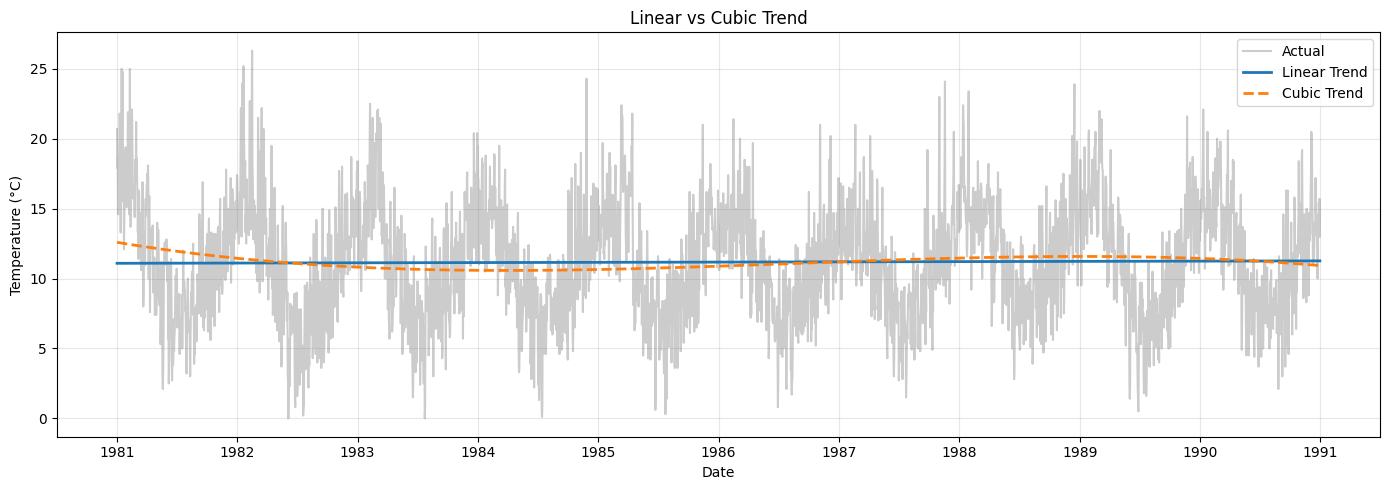

In [30]:
# YOUR CODE HERE

# Cubic trend
dp_cubic = DeterministicProcess(
    index=y.index,
    constant=True,
    order=3,
    drop=True,
)
X_cubic = dp_cubic.in_sample()
model_cubic = LinearRegression()
model_cubic.fit(X_cubic,y)
y_cubic = pd.Series(model_cubic.predict(X_cubic), index=y.index)

# Plot both on the same axes
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.4, color='gray', label='Actual')
ax.plot(y.index, y_trend.values, linewidth=2, label='Linear Trend')
ax.plot(y.index, y_cubic.values, linewidth=2, linestyle='--', label='Cubic Trend')
ax.set_title('Linear vs Cubic Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

**Your answer: The cubic trend fits the data more visually, as it models non-linear fluctuations. However, we may still prefer the linear trend over the cubic trend for forecasting because it's less likely to overfit noise and temporary fluctuations in a historical data, it's also simpler and more interpretable**



### Exercise 1.3 — Short Answer

1. What does the `constant=True` argument in `DeterministicProcess` add to the feature matrix, and why is it important?
2. Why is it risky to use a high-order polynomial (e.g. `order=11`) for forecasting *outside* the training window?

**Your answers here:**

1. constant=True adds a column of 1s to the feature matrix. This means that the model now also finds an intercept term. y=mx+c, the model now finds c term as well instead of just y=mx. This is important so as to not make the fitted line pass through the origin with zero intercept as in many real-world datasets the response variables don't start at zero.

2. High order polynomials fit the training data better but for forecasting outside the training window they're risky to use because they often learn noise and random fluctuations by overfitting the data, hence extrapolating beyong training window becomes unstable.

---
## Section 2 — Modelling Seasonality with Fourier Features

Seasonality is regular, repeating variation — e.g. temperature peaks every summer. We can encode it two ways:

| Method | How it works | Best for |
|--------|-------------|----------|
| **Seasonal indicators (dummies)** | One binary column per season (day of week, month, etc.) | Short, fixed periods |
| **Fourier features** | Pairs of sin/cos waves at different frequencies | Long or multiple periods |

`DeterministicProcess` handles both. Use `seasonal=True` for day-of-week indicators, or add a `CalendarFourier` term for longer periods like annual seasonality.

The key parameter for `CalendarFourier` is **order** — higher order captures finer seasonal detail, but risks overfitting. For our daily temperature data, we use `freq='Y'` to capture annual seasonality.

**Read:** [`CalendarFourier` docs](https://www.statsmodels.org/stable/generated/statsmodels.tsa.deterministic.CalendarFourier.html)

In [31]:
# --- EXAMPLE: What Fourier features look like ---
# freq='Y' means annual seasonality (one full cycle = one year)

fourier_ex = CalendarFourier(freq='Y', order=2)  # annual seasonality, order 2
dp_ex = DeterministicProcess(
    index=df.index,
    constant=True,
    order=1,
    additional_terms=[fourier_ex],
    drop=True,
)
X_ex = dp_ex.in_sample()
print("Columns:", X_ex.columns.tolist())
print(X_ex.head())

Columns: ['const', 'trend', 'sin(1,freq=YE-DEC)', 'cos(1,freq=YE-DEC)', 'sin(2,freq=YE-DEC)', 'cos(2,freq=YE-DEC)']
            const  trend  sin(1,freq=YE-DEC)  cos(1,freq=YE-DEC)  \
Date                                                               
1981-01-01    1.0    1.0            0.000000            1.000000   
1981-01-02    1.0    2.0            0.017213            0.999852   
1981-01-03    1.0    3.0            0.034422            0.999407   
1981-01-04    1.0    4.0            0.051620            0.998667   
1981-01-05    1.0    5.0            0.068802            0.997630   

            sin(2,freq=YE-DEC)  cos(2,freq=YE-DEC)  
Date                                                
1981-01-01            0.000000            1.000000  
1981-01-02            0.034422            0.999407  
1981-01-03            0.068802            0.997630  
1981-01-04            0.103102            0.994671  
1981-01-05            0.137279            0.990532  


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


### Exercise 2.1 — Fit a Seasonal Model

Build a model for `temp` that captures **annual seasonality** using Fourier features of order 4. Steps:
1. Create `CalendarFourier(freq='Y', order=4)`
2. Build a `DeterministicProcess` with `order=1` (linear trend) and the Fourier terms
3. Fit a `LinearRegression` and store predictions in `y_seasonal`
4. Plot the actual series and the model's fitted values

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


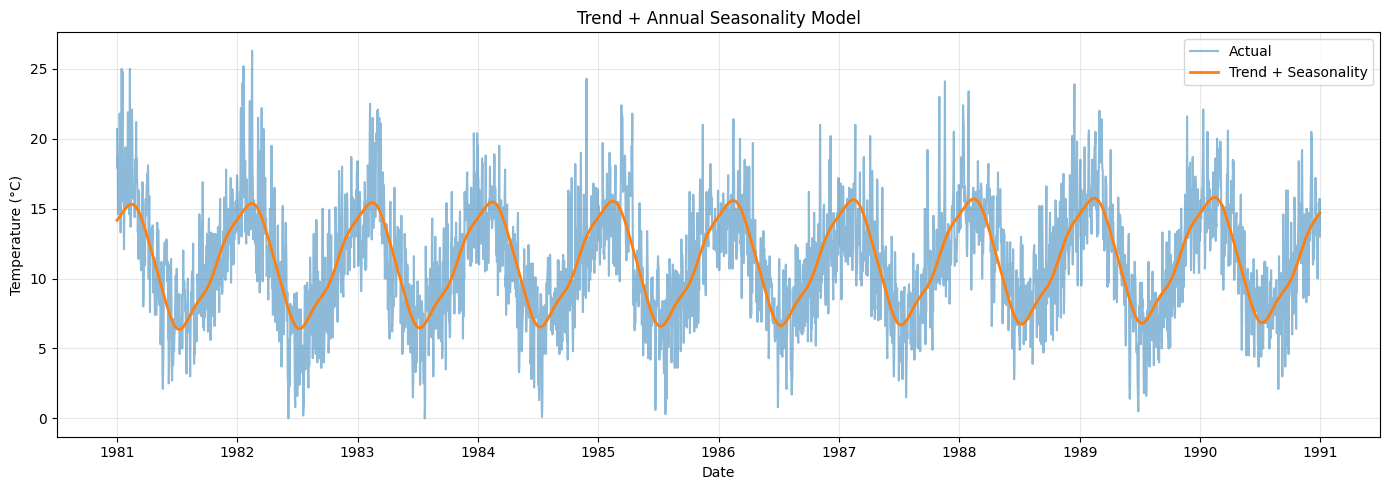

In [32]:
# YOUR CODE HERE

# 1. Fourier terms for annual seasonality (freq='Y' for daily data)
fourier = CalendarFourier(freq='Y',order=4)

# 2. DeterministicProcess with trend + Fourier
dp_seas = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    additional_terms=[fourier],
    drop=True,
)

# 3. Build feature matrix and fit model
X_seas = dp_seas.in_sample()
model_seas = LinearRegression(fit_intercept=False)
model_seas.fit(X_seas,y)
y_seasonal = pd.Series(model_seas.predict(X_seas), index=X_seas.index)

# 4. Plot
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.5, label='Actual')
ax.plot(y.index, y_seasonal.values, linewidth=2, label='Trend + Seasonality')
ax.set_title('Trend + Annual Seasonality Model')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 2.2 — Compute Residuals and Evaluate

1. Compute the residuals: `y_resid = y - y_seasonal`
2. Plot the residuals as a time series. What do you notice?
3. Compute and print the **MAE** and **RMSE** of `y_seasonal` against the actual `y`.

> **Reminder from Week 2 resources:**  
> MAE = mean of |error|  
> RMSE = square root of mean of error²

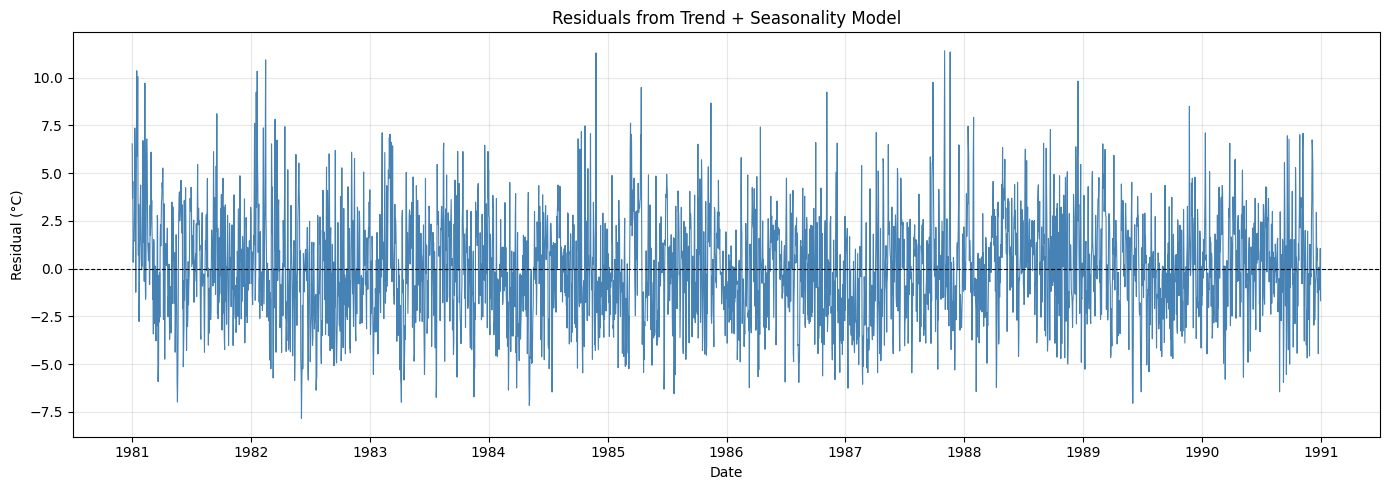

MAE:  2.167
RMSE: 2.737


In [33]:
# YOUR CODE HERE

# 1. Residuals
y_resid = y-y_seasonal

# 2. Plot residuals
fig, ax = plt.subplots()
ax.plot(y_resid.index, y_resid.values, linewidth=0.8, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Residuals from Trend + Seasonality Model')
ax.set_xlabel('Date')
ax.set_ylabel('Residual (°C)')
plt.tight_layout()
plt.show()

# 3. Metrics
mae  = mean_absolute_error(y,y_seasonal)
rmse = mean_squared_error(y,y_seasonal)**0.5
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

***What do you notice about the residuals? Is there still structure left in them?**

Answer: The residuals are centered around zero and have no trend or seasoanility in them meaning they capture the trend and seasonality of the data given. However, there are still clusters of positive and negative residuals and some large spikes, likely due to short-term temperature fluctuations and noise not captured by the model.



---
## Section 3 — Lag Features & Serial Dependence

After removing trend and seasonality, the remaining residuals may still carry information — the value today may be correlated with values from previous days. This is called **serial dependence**.

We capture it with **lag features**: `lag_1` = yesterday's value, `lag_7` = value one week ago, etc.

A **Partial Autocorrelation Function (PACF)** plot tells you which lags are *directly* predictive — it filters out indirect correlations.

**Key rule:** Always create lag features *before* splitting into train/test. Use `.shift(n)` so that at each row, the lag feature only uses *past* values — never future ones.

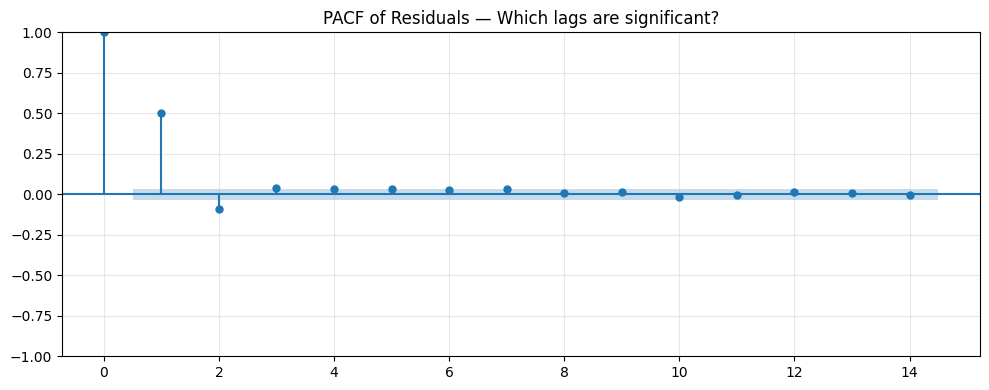

In [34]:
# --- EXAMPLE: PACF plot to identify useful lags ---

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(y_resid.dropna(), lags=14, ax=ax)
ax.set_title('PACF of Residuals — Which lags are significant?')
plt.tight_layout()
plt.show()

# Bars extending outside the shaded band are statistically significant

### Exercise 3.1 — Build Lag Features from Residuals

Based on the PACF plot above:
1. Note which lags (1 through 14) appear significant (extend outside the shaded band)
2. Create a DataFrame `df_lags` from `y_resid` with lag columns for those significant lags (at minimum include `lag_1`, `lag_2`, `lag_7`)
3. Drop rows with `NaN` values
4. Print the shape and first 5 rows

In [35]:
# YOUR CODE HERE

df_lags = pd.DataFrame({'resid': y_resid})

# Add lag features — adjust this list based on your PACF analysis
significant_lags = [1, 2, 7]  # update this after inspecting the PACF
for lag in significant_lags:
    df_lags[f'lag_{lag}'] = df_lags['resid'].shift(lag)

# Drop NaN rows
df_lags = df_lags.dropna()

print("Shape:", df_lags.shape)
print(df_lags.head())

Shape: (3643, 4)
               resid     lag_1     lag_2     lag_7
Date                                              
1981-01-08  2.999136  1.432808  1.466347  6.531873
1981-01-09  7.365346  2.999136  1.432808  3.699051
1981-01-10  5.531456  7.365346  2.999136  4.566094
1981-01-11  1.697489  5.531456  7.365346  0.332993
1981-01-12 -1.236526  1.697489  5.531456  1.499744


**Which lags did you identify as significant from the PACF, and why?**

Lag 1 and Lag 2 are definetly significant since they're PACF values are far outside the band, for lag 1 the value is 0.5 and for lag 2 it's approx. -0.1. We also include lag 7 since it may capture a weekly effect even though pacf value is small as compared to 1 and 2.



### Exercise 3.2 — Fit a Linear Model on Lag Features

Split `df_lags` into train (80%) and test (20%) using a **time-ordered split** (no shuffling). Then:
1. Fit a `LinearRegression` model to predict `resid` from the lag features
2. Generate predictions on the test set
3. Compute and print MAE and RMSE on the test set
4. Plot actual vs predicted residuals for the test period

Test MAE:  1.699
Test RMSE: 2.142


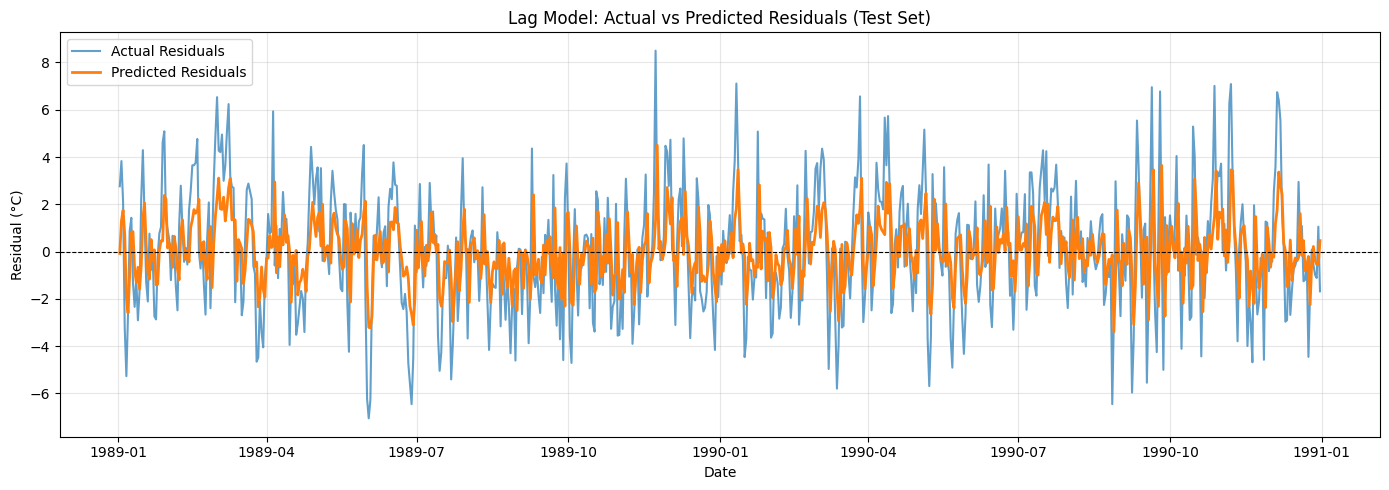

In [36]:
# YOUR CODE HERE

# 1. Time-ordered train/test split (no shuffling!)
split_idx = int(len(df_lags) * 0.8)
train = df_lags.iloc[:split_idx]
test  = df_lags.iloc[split_idx:]

feature_cols = [c for c in df_lags.columns if c != 'resid']
X_train, y_train = train[feature_cols], train['resid']
X_test,  y_test  = test[feature_cols],  test['resid']

# 2. Fit LinearRegression
model_lag = LinearRegression()
model_lag.fit(X_train,y_train)

# 3. Predict and evaluate
y_pred_lag = pd.Series(model_lag.predict(X_test), index=y_test.index)
mae_lag  = mean_absolute_error(y_test, y_pred_lag)
rmse_lag = mean_squared_error(y_test, y_pred_lag)**0.5
print(f"Test MAE:  {mae_lag:.3f}")
print(f"Test RMSE: {rmse_lag:.3f}")

# 4. Plot actual vs predicted
fig, ax = plt.subplots()
ax.plot(y_test.index, y_test.values, label='Actual Residuals', alpha=0.7)
ax.plot(y_test.index, y_pred_lag, label='Predicted Residuals', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Lag Model: Actual vs Predicted Residuals (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Residual (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 3.3 — Short Answer

1. Why must we use a **time-ordered split** (not a random split) when evaluating time series models?
2. Why did we fit the lag model on *residuals* rather than on the raw temperature values?
3. In a multi-agent system, one agent captures trend and seasonality. What would a second agent specialised in lag features add on top of that?

**Your answers here:**

1. It is because the time series data are not independant of each other and they're not identically distributed unlike most other data used in ML models. Here, the order matters so we used a time-ordered split to train the model using past data to predict future data, a random split might give rise to the model being trained on future data instead which is unwanted.

2. Since we're taking y = trend + seasonality + residual, the trend and seasonality part has been already covered in the previous fits, hence the lag model predicts residuals. Residuals contain short term features like noise, and autocorellation not explained by trend + seasonality, if we apply lag model to raw values then long term and short term features will mix up and model becomes unstable and more prone to overfitting.

3. Agent 1: trend and seasonality , Agent 2: lag features
Agent 1 captures the long term features but it's unable to explain the short-term noises and random fluctuations. Agent 2, speacialised in lag features adds the short term dynamics into the system. It explains the short term features for example: if it was hot on monday, it's most likely going to be hot on tuesday. It also captures sudden spikes and autocorrelations. If the first agent misses something, the second agent corrects it using recent history.

---
## Section 4 — Decision Trees, Random Forests, and XGBoost for Time Series

Linear regression can only capture straight-line relationships. **Tree-based models** can capture non-linear interactions between features with no extra engineering.

| Model | Core idea | Key hyperparameter |
|---|---|---|
| **Decision Tree** | Splits data on thresholds to minimise prediction error | `max_depth` — controls overfitting |
| **Random Forest** | Average of many trees trained on random subsets of data and features | `n_estimators` — number of trees |
| **XGBoost** | Trees trained *sequentially*, each correcting the last tree's errors | `n_estimators`, `learning_rate` |

**Important:** None of these models has a built-in notion of time. To use them for time series, we feed them the same lag and calendar features we've been building — the model then learns patterns from those features.

**Read:** [XGBoost docs](https://xgboost.readthedocs.io/en/stable/)

In [37]:
# --- EXAMPLE: Building a rich feature set for tree-based models ---
# Note: we build these from the RAW temperature series `y`,
# because tree models will learn to separate trend/seasonality/residuals on their own.

def make_features(series, lags=[1, 2, 7, 14], rolling_windows=[7, 28]):
    """Create lag and rolling features from a time series."""
    df_feat = pd.DataFrame({'target': series})

    # Calendar features (encode time structure)
    df_feat['dayofyear'] = series.index.dayofyear
    df_feat['month']     = series.index.month
    df_feat['dayofweek'] = series.index.dayofweek

    # Lag features (serial dependence)
    for lag in lags:
        df_feat[f'lag_{lag}'] = series.shift(lag)

    # Rolling statistics on lagged values (shift(1) avoids lookahead leakage)
    for w in rolling_windows:
        df_feat[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        df_feat[f'roll_std_{w}']  = series.shift(1).rolling(w).std()

    return df_feat.dropna()

df_tree = make_features(y)
feature_cols_tree = [c for c in df_tree.columns if c != 'target']
print("Feature matrix shape:", df_tree.shape)
print("Features:", feature_cols_tree)
print(df_tree.head())

Feature matrix shape: (3622, 12)
Features: ['dayofyear', 'month', 'dayofweek', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28']
            target  dayofyear  month  dayofweek  lag_1  lag_2  lag_7  lag_14  \
Date                                                                           
1981-01-29    15.5         29      1          3   17.2   19.4   12.1    25.0   
1981-01-30    15.1         30      1          4   15.5   17.2   14.4    20.7   
1981-01-31    15.4         31      1          5   15.1   15.5   16.0    20.6   
1981-02-01    15.3         32      2          6   15.4   15.1   16.5    24.8   
1981-02-02    18.8         33      2          0   15.3   15.4   18.7    17.7   

            roll_mean_7  roll_std_7  roll_mean_28  roll_std_28  
Date                                                            
1981-01-29    16.328571    2.501809     17.967857     3.131921  
1981-01-30    16.814286    1.765813     17.782143     3.118054  
198

In [38]:
# --- EXAMPLE: Time-ordered train/test split ---

split_idx_tree = int(len(df_tree) * 0.8)
X_train_tree = df_tree.iloc[:split_idx_tree][feature_cols_tree]
y_train_tree = df_tree.iloc[:split_idx_tree]['target']
X_test_tree  = df_tree.iloc[split_idx_tree:][feature_cols_tree]
y_test_tree  = df_tree.iloc[split_idx_tree:]['target']

print(f"Train size: {len(X_train_tree)} | Test size: {len(X_test_tree)}")

Train size: 2897 | Test size: 725


### Exercise 4.1 — Decision Tree

Fit a `DecisionTreeRegressor` with `max_depth=4` on the training data. Predict on the test set and compute MAE and RMSE.

Then try `max_depth=None` (fully grown tree). Compare the two results — what do you observe? What term describes what happens with `max_depth=None`?

In [39]:
# YOUR CODE HERE

# Decision tree with max_depth=4
model_dt = DecisionTreeRegressor(max_depth=4)
model_dt.fit(X_train_tree, y_train_tree)
y_pred_dt = pd.Series(model_dt.predict(X_test_tree))
mae_dt  = mean_absolute_error(y_test_tree, y_pred_dt)
rmse_dt = mean_squared_error(y_test_tree, y_pred_dt)**0.5
print(f"Decision Tree (max_depth=4)  — MAE: {mae_dt:.3f} | RMSE: {rmse_dt:.3f}")

# Decision tree with max_depth=None (fully grown)
model_dt_full = DecisionTreeRegressor(max_depth=None)
model_dt_full.fit(X_train_tree, y_train_tree)
y_pred_dt_full = pd.Series(model_dt_full.predict(X_test_tree))
mae_dt_full  = mean_absolute_error(y_test_tree, y_pred_dt_full)
rmse_dt_full = mean_squared_error(y_test_tree, y_pred_dt_full)**0.5
print(f"Decision Tree (max_depth=None) — MAE: {mae_dt_full:.3f} | RMSE: {rmse_dt_full:.3f}")

Decision Tree (max_depth=4)  — MAE: 1.829 | RMSE: 2.317
Decision Tree (max_depth=None) — MAE: 2.656 | RMSE: 3.337


**What happens when `max_depth=None`? Name the phenomenon and explain why it's a problem for forecasting.**

When max_depth=None, the decision tree is fully grown and results in overfitting of training data. It learns not only the underlying patterns but also random noise and anomalies, since after a certain deapth the number of data points are too low and splitting to form newer sets results in this overfitting. Hence, poor performance of max_depth=none is seen in the test data as compared to max_depth=4. Overfitting is problematic for forecasting because future observations differ from the training data, so a model that is so well trained on training data doesn't perform well with new unseen data.

### Exercise 4.2 — Random Forest

Fit a `RandomForestRegressor` with `n_estimators=100` and `random_state=42`. Predict on the test set, compute MAE and RMSE, and plot actual vs predicted temperature.

Random Forest — MAE: 1.690 | RMSE: 2.161


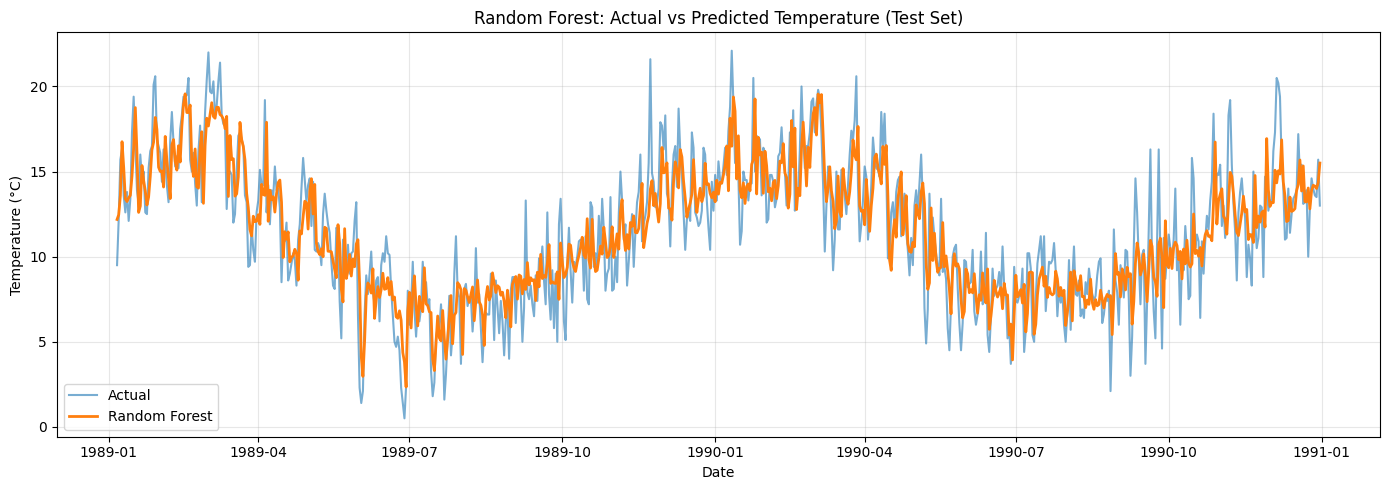

In [40]:
# YOUR CODE HERE

# Fit RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_tree, y_train_tree)

# Predict and evaluate
y_pred_rf = pd.Series(model_rf.predict(X_test_tree))
mae_rf  = mean_absolute_error(y_test_tree, y_pred_rf)
rmse_rf = mean_squared_error(y_test_tree, y_pred_rf)**0.5
print(f"Random Forest — MAE: {mae_rf:.3f} | RMSE: {rmse_rf:.3f}")

# Plot
fig, ax = plt.subplots()
ax.plot(y_test_tree.index, y_test_tree.values, alpha=0.6, label='Actual')
ax.plot(y_test_tree.index, y_pred_rf, linewidth=2, label='Random Forest')
ax.set_title('Random Forest: Actual vs Predicted Temperature (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 4.3 — XGBoost and Feature Importance

Fit an `XGBRegressor` with `n_estimators=100` and `learning_rate=0.1`. Then:
1. Predict on the test set and compute MAE and RMSE
2. Plot the **top 10 feature importances** as a horizontal bar chart using `model_xgb.feature_importances_`
3. Which features are most important? Does this match your intuition from earlier sections?

XGBoost — MAE: 1.773 | RMSE: 2.240


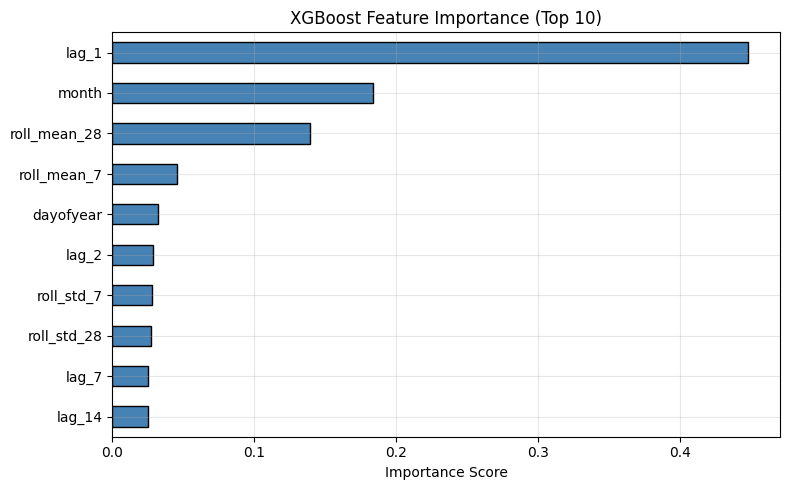

In [41]:
# YOUR CODE HERE

# 1. Fit XGBRegressor
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
model_xgb.fit(X_train_tree, y_train_tree)

# Predict and evaluate
y_pred_xgb = pd.Series(model_xgb.predict(X_test_tree))
mae_xgb  = mean_absolute_error(y_test_tree, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test_tree, y_pred_xgb)**0.5
print(f"XGBoost — MAE: {mae_xgb:.3f} | RMSE: {rmse_xgb:.3f}")

# 2. Feature importance plot
importance = pd.Series(
    model_xgb.feature_importances_,
    index=feature_cols_tree
).sort_values(ascending=True).tail(10)  # top 10

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('XGBoost Feature Importance (Top 10)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Your interpretation: which features dominate, and why does that make sense for temperature data?**

The most dominant feature is lag_1, which shows that temperature of a certain day is highly predictable by seeing the temperature just the day before it (basically lag 1 had the highest average gain). This matches the PACF analysis, which showed strong serial dependence at lag 1. The next important features are month and dayofyear because temperature shows lesser than lag 1 but still significant correlation to these seasonal cycles.


### Exercise 4.4 — Short Answer

1. Why does Random Forest generally outperform a single Decision Tree? (Hint: think about the word *ensemble*.)
2. XGBoost and Random Forest are both ensembles of trees, but they're built differently. What is the key difference in *how* each ensemble is constructed?
3. In the multi-agent forecasting project, if you assigned one agent to use XGBoost, what would be important to tell it about feature engineering — specifically about avoiding leakage?

**Your answers here:**

1. Random Forest generally outperforms a single Decision Tree because it is an ensemble of many trees trained on different bootstrap samples and feature subsets. Averaging the predictions reduces variance and overfitting, leading to better generalization on unseen data.

2. Random Forest builds many trees independently and averages their predictions, while XGBoost builds trees sequentially, with each new tree focusing on correcting the errors made by the previous ensemble. Random Forest uses bagging, whereas XGBoost uses boosting.

3. An XGBoost forecasting agent must ensure that all engineered features are based only on information available at prediction time. Lag features should be created using .shift, and rolling statistics should be computed on shifted values. Any feature that directly or indirectly uses future observations would introduce data leakage and lead to unrealistically optimistic evaluation results.


---
## Section 5 — Hybrid Models: Linear + XGBoost

Neither a pure linear model nor a pure XGBoost model is always best. A **hybrid** combines their strengths:

1. **Model 1 (Linear Regression)** captures the global structure — trend and seasonality
2. **Model 2 (XGBoost)** captures what's *left over* — the residuals, which contain serial dependence and non-linear patterns
$$
\hat{y} = \underbrace{\hat{y}_{\text{linear}}}_\text{trend + seasonality} + \underbrace{\hat{y}_{\text{XGB}}}_\text{residuals}
$$

This decomposition is clean: each model gets the job it's best suited for. It's the same principle used by many Kaggle competition winners.

In [42]:
# --- EXAMPLE: BoostedHybrid class ---

class BoostedHybrid:
    """
    A two-stage hybrid forecaster:
      model_1: captures deterministic structure (trend + seasonality)
      model_2: captures remaining signal in the residuals
    """
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2

    def fit(self, X_1, X_2, y):
        """X_1 = features for model_1, X_2 = features for model_2, y = target"""
        # Step 1: Fit model_1 on X_1
        self.model_1.fit(X_1, y)

        # Step 2: Compute residuals — what model_1 could not explain
        y_fit        = pd.Series(self.model_1.predict(X_1), index=X_1.index)
        self.y_resid = y - y_fit

        # Step 3: Fit model_2 on the residuals
        self.model_2.fit(X_2, self.y_resid)

    def predict(self, X_1, X_2):
        """Combined prediction = model_1 prediction + model_2 prediction on residuals"""
        y_pred_1 = pd.Series(self.model_1.predict(X_1), index=X_1.index)
        y_pred_2 = pd.Series(self.model_2.predict(X_2), index=X_2.index)
        return y_pred_1 + y_pred_2

print("BoostedHybrid class defined!")

BoostedHybrid class defined!


### Exercise 5.1 — Train the Hybrid Model

Train a `BoostedHybrid` on the temperature data using:
- `model_1` = `LinearRegression(fit_intercept=False)` with `X_seas` (trend + Fourier features from Section 2)
- `model_2` = `XGBRegressor(n_estimators=100, learning_rate=0.1)` with the lag/rolling features from Section 4

Steps:
1. Align the two feature sets to a common index (they may start at different rows due to lag NaN dropping)
2. Split into train (80%) and test (20%)
3. Fit the hybrid on training data
4. Predict on test data
5. Compute MAE and RMSE

In [43]:
# YOUR CODE HERE

# 1. Align both feature sets and the target to a shared index
common_idx = X_seas.index.intersection(df_tree.index)
y_common   = y.loc[common_idx]
X1_common  = X_seas.loc[common_idx]                     # for LinearRegression
X2_common  = df_tree.loc[common_idx, feature_cols_tree] # for XGBoost

# 2. Time-ordered split
split = int(len(common_idx) * 0.8)
X1_train, X1_test = X1_common.iloc[:split], X1_common.iloc[split:]
X2_train, X2_test = X2_common.iloc[:split], X2_common.iloc[split:]
y_train_h, y_test_h = y_common.iloc[:split], y_common.iloc[split:]

# 3. Instantiate and fit the hybrid model
hybrid = BoostedHybrid(
    model_1= LinearRegression(fit_intercept=False),
    model_2=XGBRegressor(n_estimators=100, learning_rate=0.1)
)
hybrid.fit(X1_train, X2_train, y_train_h)

# 4. Predict on test set
y_pred_hybrid = hybrid.predict(X1_test, X2_test)

# 5. Evaluate
mae_hybrid  = mean_absolute_error(y_test_h, y_pred_hybrid)
rmse_hybrid = mean_squared_error(y_test_h, y_pred_hybrid)**0.5
print(f"Hybrid Test MAE:  {mae_hybrid:.3f}")
print(f"Hybrid Test RMSE: {rmse_hybrid:.3f}")

Hybrid Test MAE:  1.743
Hybrid Test RMSE: 2.227


### Exercise 5.2 — Compare All Models

Fill in the comparison table below with the test-set MAE and RMSE you computed for each model. Then answer the questions below.

| Model | Test MAE | Test RMSE |
|---|---|---|
| Trend + Seasonality (Linear) | 2.167 | 2.737 |
| Lag Features (Linear, on residuals) | 1.699|2.142|
| Decision Tree (max_depth=4) |1.829 | 2.317 |
| Random Forest |  1.690 | 2.161|
| XGBoost | 1.773 | 2.240 |
| Hybrid (Linear + XGBoost) |1.743 | 2.227|

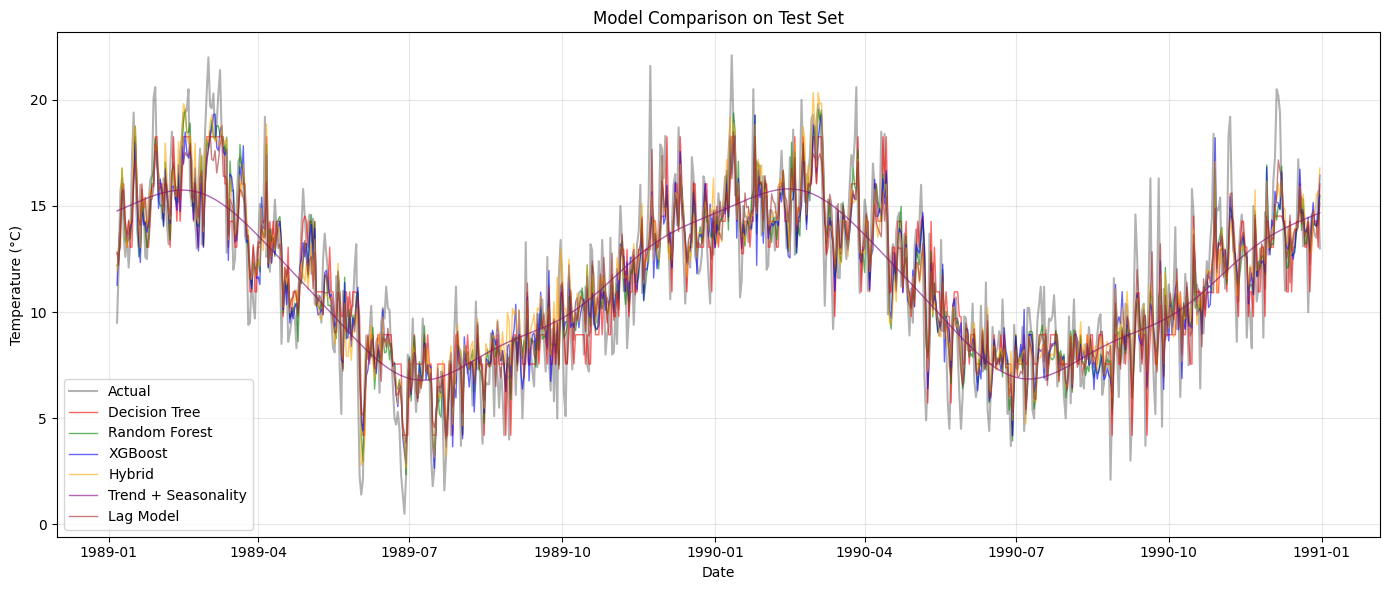

In [44]:
# YOUR CODE HERE — Plot all models' predictions on the test set for a visual comparison
# Tip: use y_test_h as your actual test target (it corresponds to the hybrid's test period)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test_h.index, y_test_h.values, color='black', alpha=0.3, linewidth=1.5, label='Actual')
# Add your model predictions here ...
ax.plot(y_test_h.index, y_pred_dt.values, color='red', alpha=0.6, linewidth=1, label='Decision Tree')
ax.plot(y_test_h.index, y_pred_rf.values, color='green', alpha=0.6, linewidth=1, label='Random Forest')
ax.plot(y_test_h.index, y_pred_xgb.values, color='blue', alpha=0.6, linewidth=1, label='XGBoost')
ax.plot(y_test_h.index, y_pred_hybrid.values, color='orange', alpha=0.6, linewidth=1, label='Hybrid')
ax.plot(y_test_h.index, y_seasonal.loc[y_test_h.index].values, color='purple', alpha=0.6, linewidth=1, label='Trend + Seasonality')
ax.plot(y_test_h.index, y_pred_lag.loc[y_test_h.index].values + y_seasonal.loc[y_test_h.index].values, color='brown', alpha=0.6, linewidth=1, label='Lag Model')
ax.set_title('Model Comparison on Test Set')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

**Questions:**

1. Which model performed best? Was this what you expected?
2. Why might the hybrid outperform both individual models?
3. In a multi-agent forecasting system, how could you assign different models to different agents and combine their outputs into one forecast?

**Your answers:**

1. The model which performed the best was the random forest model, which was closely followed up by the hybrid model. This is partially what we expected, even though majority of times hybrid models may outperform, but in general tree ensembles perform extremely well for this dataset.

2. The hybrid model can outperform individual models because it decomposes the forecasting task into two complementary components. The linear model captures structured and predictable patterns such as trend and seasonality, while the XGBoost model focuses on the residual errors, learning nonlinear relationships and short-term fluctuations that the linear model cannot capture. But the hybrid highly relies on tuning (gamma, lamda, max deapth, learning rate), if tuned the hybrid would have most likely outperformed the random forest in this dataset as well.

3. In a multi-agent forecasting system, different models can be treated as specialized agents, each responsible for learning a specific aspect of the data. For example, a linear regression agent can model long-term trend and seasonality using time-based or Fourier features, while a tree-based agent such as XGBoost or Random Forest can capture nonlinear relationships using lag and rolling features. The outputs of these agents can then be combined using methods such as weighted averaging, where each model’s prediction is assigned a learned or manually tuned weight.

---
## Section 6 — Putting It All Together: Multi-Step Forecasting

So far we've evaluated models on a held-out test set within the training period. Real forecasting problems need a **forecast horizon** — predicting multiple future steps *beyond* all known data.

There are two main strategies for multi-step forecasting:

| Strategy | How it works | Trade-off |
|---|---|---|
| **Recursive** | Use the model's own predictions as lag inputs for the next step | Errors can compound step by step |
| **Direct** | Train a separate model for each future horizon step | More models, but errors stay independent |

In this section you'll apply everything you've learned to the **Air Passengers** dataset from Week 1 and build a complete hybrid forecast for 12 months ahead.

Air Passengers shape: (144,)


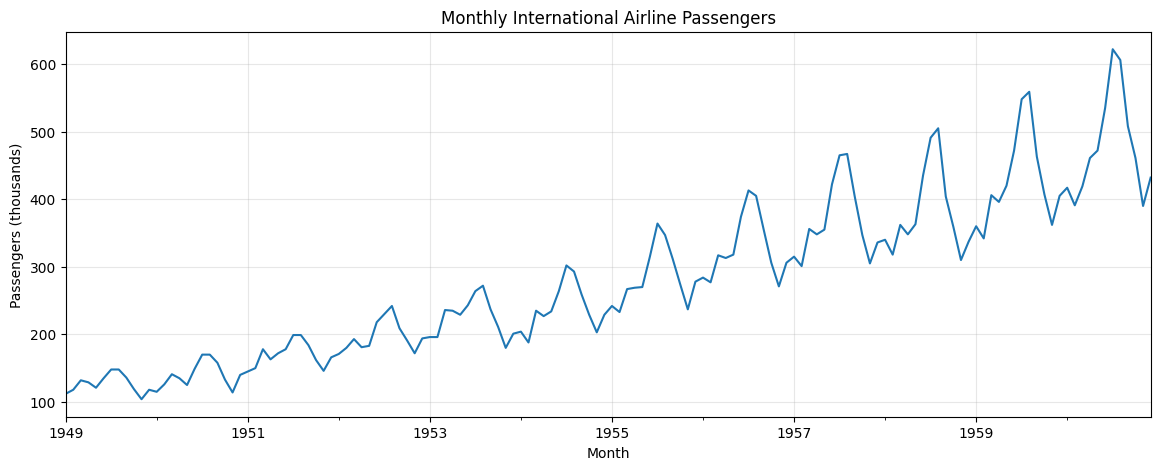

In [45]:
# Load Air Passengers
url_air = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
air = pd.read_csv(url_air, parse_dates=['Month'], index_col='Month')
air.columns = ['passengers']
air.index.freq = 'MS'

y_air = air['passengers'].astype(float)

print("Air Passengers shape:", y_air.shape)
y_air.plot(title='Monthly International Airline Passengers', ylabel='Passengers (thousands)');

### Exercise 6.1 — Build a Complete Forecasting Pipeline

Build a hybrid forecasting model for Air Passengers and forecast the last **12 months** as the held-out test set.

Follow these steps:
1. **Split:** Hold out the last 12 months as test. Use the rest as training.
2. **Model 1 — Trend + Seasonality:** Use `DeterministicProcess` with `order=1` and `CalendarFourier(freq='Y', order=4)`. Fit a `LinearRegression(fit_intercept=False)`. Compute training residuals.
3. **Model 2 — Residuals:** Build `lag_1` and `lag_12` features from the training residuals. Fit an `XGBRegressor(n_estimators=100, learning_rate=0.1)` on them.
4. **Forecast:** For Model 1, use `dp_air.out_of_sample(steps=12)`. For Model 2, use the last known residuals from training as lag inputs.
5. **Evaluate:** Compute MAE and RMSE on the test set.
6. **Plot:** Show training data, test actuals, and your forecast on one plot.

In [46]:
# Step 1: Train/test split — last 12 months as test
y_train_air = y_air.iloc[:-12]
y_test_air  = y_air.iloc[-12:]

print(f"Train: {y_train_air.index[0]} to {y_train_air.index[-1]} ({len(y_train_air)} months)")
print(f"Test:  {y_test_air.index[0]} to {y_test_air.index[-1]}  ({len(y_test_air)} months)")

Train: 1949-01-01 00:00:00 to 1959-12-01 00:00:00 (132 months)
Test:  1960-01-01 00:00:00 to 1960-12-01 00:00:00  (12 months)


In [47]:
# Step 2: Model 1 — Trend + Annual Seasonality
# YOUR CODE HERE

fourier_air = CalendarFourier(freq='Y', order=4)
dp_air = DeterministicProcess(
    index=y_train_air.index,
    constant=True,
    order=1,
    additional_terms=[fourier_air],
    drop=True,
)
X_train_air = dp_air.in_sample()

model1_air = LinearRegression(fit_intercept=False)
model1_air.fit(X_train_air, y_train_air)

# Training fitted values and residuals
y_fit_air   = pd.Series(model1_air.predict(X_train_air), index=X_train_air.index)
y_resid_air = y_train_air - y_fit_air

print("Residuals stats:")
print(y_resid_air.describe().round(2))

Residuals stats:
count    132.00
mean       0.00
std       22.87
min      -38.07
25%      -16.31
50%       -1.16
75%       14.09
max       82.02
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [48]:
# Step 3: Model 2 — XGBoost on residuals
# YOUR CODE HERE

df_resid_air = pd.DataFrame({'resid': y_resid_air})
df_resid_air['lag_1']  = df_resid_air['resid'].shift(1)
df_resid_air['lag_12'] = df_resid_air['resid'].shift(12)
df_resid_air = df_resid_air.dropna()

X_resid_train = df_resid_air[['lag_1', 'lag_12']]
y_resid_train = df_resid_air['resid']

model2_air = XGBRegressor(n_estimators=100, learning_rate=0.1)
model2_air.fit(X_resid_train, y_resid_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
# Step 4: Forecast the 12 test months
# YOUR CODE HERE

# Model 1 forecast: out-of-sample deterministic features
X_test_air_m1 = dp_air.out_of_sample(steps=12)
y_fore_m1 = pd.Series(model1_air.predict(X_test_air_m1), index=X_test_air_m1.index)

# Model 2 forecast: use the last 12 known residuals as lag_12 values,
# and the last residual as lag_1 for each test step.
# (This is a simplified one-shot approach — see Bonus for the recursive version.)
X_test_m2 = pd.DataFrame(
    {
        'lag_1':  [y_resid_air.iloc[-1]] * 12,         # last training residual
        'lag_12': y_resid_air.iloc[-12:].values,        # residuals from 12 months ago
    },
    index=y_test_air.index
)
y_fore_m2 = pd.Series(model2_air.predict(X_test_m2), index=y_test_air.index)

# Combined forecast
y_forecast = y_fore_m1.values + y_fore_m2.values  # align by position
y_forecast = pd.Series(y_forecast, index=y_test_air.index)

# Step 5: Evaluate
mae_air  = mean_absolute_error(y_test_air, y_forecast)
rmse_air = mean_squared_error(y_test_air, y_forecast) ** 0.5
print(f"12-Month Forecast MAE:  {mae_air:.1f} passengers")
print(f"12-Month Forecast RMSE: {rmse_air:.1f} passengers")

12-Month Forecast MAE:  33.7 passengers
12-Month Forecast RMSE: 41.7 passengers


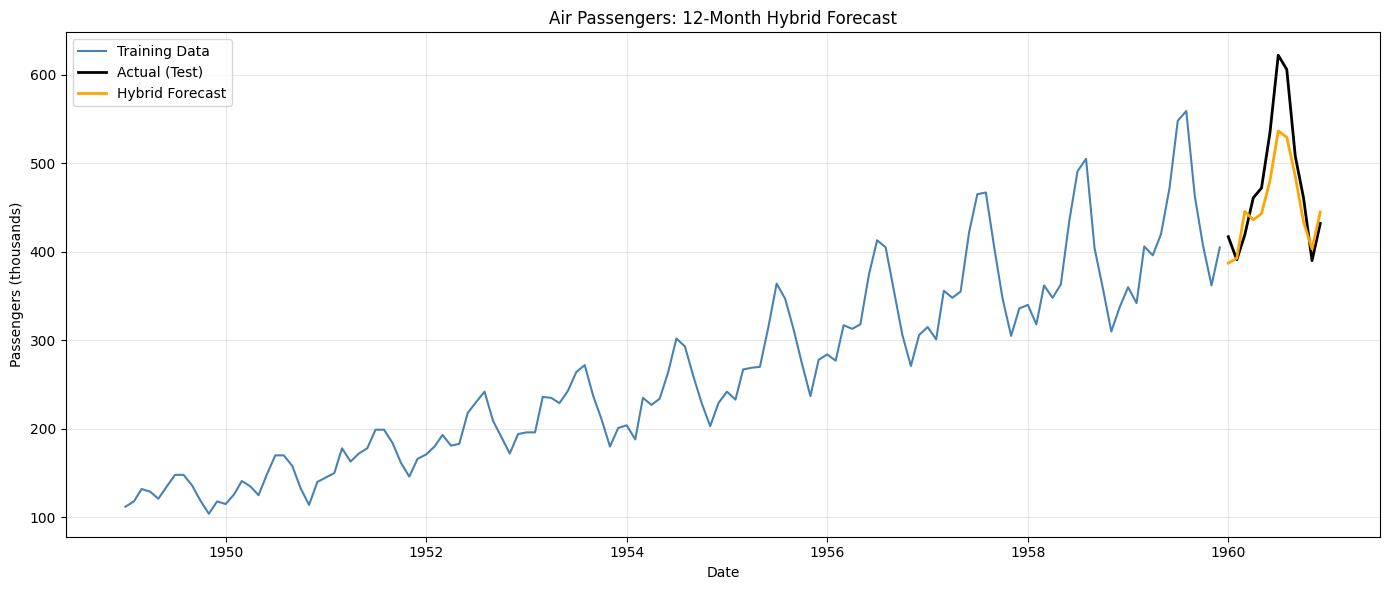

In [50]:
# Step 6: Plot — YOUR CODE HERE

fig, ax = plt.subplots(figsize=(14, 6))

# Plot training data
ax.plot(y_train_air.index, y_train_air.values, label='Training Data', color='steelblue')
# Plot test actuals
ax.plot(y_test_air.index, y_test_air.values, label='Actual (Test)', color='black', linewidth=2)
# Plot forecast — YOUR CODE HERE
# ...
ax.plot(y_forecast.index, y_forecast.values, label='Hybrid Forecast', color='orange', linewidth=2)
ax.set_title('Air Passengers: 12-Month Hybrid Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 6.2 — Reflection

Answer in 4–6 sentences, connecting your experience across all sections:

1. Walk through the modelling pipeline you just built step by step. What does each component (Model 1 and Model 2) capture that the other cannot?
2. How did the model handle the upward trend in Air Passengers? How would you improve the forecast if the trend were non-linear?
3. Thinking ahead to the multi-agent forecasting project: if each agent specialised in one model type (e.g. one agent uses only the seasonality model, another uses only XGBoost), how could you combine their outputs into a single forecast? What would be the advantage over having a single agent do everything?

**Your answer here:**
1. The forecasting pipeline consists of two stages. The first model uses a deterministic process with a linear regression model to capture the global structure of the time series, specifically the long-term trend and yearly seasonality using Fourier terms. The second model is trained on the residuals of the first model and uses XGBoost with lag features to capture short-term dependencies and nonlinear patterns that are not explained by the trend-seasonality model. Thus, Model 1 captures smooth, predictable structure in the data, while Model 2 focuses on correcting local deviations and irregular fluctuations.

2. The upward trend in Air Passengers is handled by the linear trend component of the DeterministicProcess, which models the increase as a linear function over time. This works well when the trend is approximately linear. However, if the trend were nonlinear (for example, exponential growth), a linear trend would underfit the data. In such cases, the model could be improved by using higher-order polynomial terms in the deterministic process, applying a log transformation to the target variable, or using more flexible models such as tree-based models to capture nonlinear growth patterns.

3. In a multi-agent forecasting system, each agent can specialize in a different aspect of the time series. For example, one agent could focus on trend and seasonality using a deterministic or linear model, while another agent focuses on short-term dependencies using XGBoost. A final combining mechanism, such as weighted averaging or stacking, can be used to merge their predictions into a single forecast. This approach is advantageous because it decomposes a complex problem into simpler specialized tasks, allowing each model to perform what it is best at, rather than relying on a single model to learn all patterns simultaneously, which improves both interpretability and accuracy.

---
## Bonus Challenge ⭐

Improve the Air Passengers hybrid forecast by trying **at least two** of the following modifications. For each, report the new test MAE and RMSE and explain whether it helped.

- **A.** Increase the Fourier order from 4 to 6. Does adding more Fourier terms help or overfit?
- **B.** Add a `lag_6` feature (6-month lag) to Model 2 alongside `lag_1` and `lag_12`.
- **C.** Implement a proper **recursive** multi-step forecast for Model 2: at each of the 12 test steps, predict one residual, then use *that prediction* as `lag_1` for the next step. Compare its MAE to the simplified approach in Exercise 6.1.
- **D.** Swap XGBoost for `RandomForestRegressor` in Model 2. Does it perform better or worse?
- **E.** Use `order=2` (quadratic trend) in the DeterministicProcess. Does a curved trend fit Air Passengers better?

In [51]:
# BONUS — YOUR CODE HERE
# Try at least two modifications and report results


**Bonus findings:**



---
## Submission Checklist

Before submitting, make sure:
- [ ] All `# YOUR CODE HERE` cells are filled in and run without errors
- [ ] All short-answer and reflection cells are filled in
- [ ] All plots have titles, axis labels, and legends
- [ ] The comparison table in Section 5.2 is filled in with actual numbers from your runs
- [ ] The notebook runs top-to-bottom with **Kernel → Restart & Run All**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week2_Assignment_YourName.ipynb`